# Projeto 1 - Pipeline MLP (Breast Cancer Wisconsin)

Pipeline completo de deep learning ponta a ponta: MLP construído do zero em PyTorch
(`nn.Module`, sem Lightning), diagnosticado e estabilizado. Um único dataset --
**Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) -- usado nas
duas variantes do problema:

- **Parte 1 -- Classificação**: alvo binário (maligno/benigno), 30 features de entrada.
- **Parte 2 -- Regressão**: alvo contínuo (`mean concavity`), previsto a partir das
  outras 27 features (as 3 relacionadas à mesma grandeza -- `concavity error` e
  `worst concavity` -- são removidas da entrada pra evitar vazamento de alvo).

Ambos os problemas passam pelo mesmo pipeline: split 70/15/15, DataLoader, checkpoint
via `state_dict`, gradient norm tracking, comparação de inicialização de pesos,
comparação de ativação, comparação de normalização/dropout, tuning via Optuna,
LR scheduling monitorado no TensorBoard.


In [ ]:
import os
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)

import optuna

# Configuração de sementes para reprodutibilidade estrita
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Usando dispositivo: {device}")
print(f"🔥 PyTorch: {torch.__version__}")

# Verificação do ambiente (PyTorch + TensorBoard) antes de qualquer treino
_writer_check = SummaryWriter(log_dir="runs/_env_check")
_writer_check.add_scalar("check/ok", 1.0, 0)
_writer_check.close()
print("✅ TensorBoard verificado -- logs de teste gravados em runs/_env_check")


🚀 Usando dispositivo: cpu
🔥 PyTorch: 2.13.0+cpu
✅ TensorBoard verificado -- logs de teste gravados em runs/_env_check


## Parte 1 -- Classificação (Breast Cancer Wisconsin)

In [ ]:
# 1. Carregar dataset
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target
target_names = data.target_names

print(f"📊 Dimensão do dataset: {X_raw.shape} (linhas, colunas)")
print(f"🏷️ Classes: {list(target_names)} -- 0 = maligno, 1 = benigno")

unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   • Classe {u} ({target_names[u]}): {c} amostras ({c/len(y_raw)*100:.1f}%)")

# Não há colunas categóricas aqui (as 30 features do dataset já são todas numéricas
# contínuas) -- diferente do exemplo de e-commerce, não precisa de ColumnTransformer
# nem OneHotEncoder, só StandardScaler.

# 2. Split 70% treino / 15% validação / 15% teste, estratificado
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 3. Padronização -- fit exclusivo no treino, evita vazamento de dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"\n✅ Formato X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")


📊 Dimensão do dataset: (569, 30) (linhas, colunas)
🏷️ Classes: [np.str_('malignant'), np.str_('benign')] -- 0 = maligno, 1 = benigno
   • Classe 0 (malignant): 212 amostras (37.3%)
   • Classe 1 (benign): 357 amostras (62.7%)

✅ Formato X_train: (398, 30) | X_val: (85, 30) | X_test: (86, 30)


In [ ]:
class TabularDataset(Dataset):
    """Dataset genérico p/ classificação binária (alvo float, shape (N,1)) e regressão."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"🚚 DataLoaders criados com batch_size = {batch_size}:")
print(f"   • Lotes de Treino:    {len(train_loader)} batches")
print(f"   • Lotes de Validação: {len(val_loader)} batches")
print(f"   • Lotes de Teste:     {len(test_loader)} batches")

first_X_batch, first_y_batch = next(iter(train_loader))
print(f"\n🧩 Primeiro lote: X {first_X_batch.shape} | y {first_y_batch.shape}")


🚚 DataLoaders criados com batch_size = 64:
   • Lotes de Treino:    7 batches
   • Lotes de Validação: 2 batches
   • Lotes de Teste:     2 batches

🧩 Primeiro lote: X torch.Size([64, 30]) | y torch.Size([64, 1])


### Justificativa da arquitetura (profundidade x largura)

O dataset tem **30 features** contínuas e só **398 amostras de treino** -- é pequeno e,
empiricamente, quase linearmente separável (uma Regressão Logística simples já chega
perto de 98% de acurácia, ver baseline abaixo). Isso limita quanto a rede pode ganhar
com profundidade:

- **Rede funda (4+ camadas)** teria muito mais parâmetros do que dado para sustentar
  -- overfitting praticamente garantido, e mais risco de gradiente instável sem
  regularização pesada.
- **Rede rasa (1-3 camadas ocultas, 32-128 neurônios)** dá capacidade suficiente pra
  capturar eventual interação não-linear entre as features sem superdimensionar o
  modelo pro tamanho do dataset.

Por isso a busca do Optuna (mais abaixo) varre `n_layers` entre 1 e 3 e `n_units` entre
32 e 128 -- a faixa já nasce restrita pela análise acima, o Optuna só confirma
empiricamente qual ponto dentro dela funciona melhor.


In [ ]:
class TabularMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        activation_cls=nn.ReLU,
        norm_type=None,
        dropout_rate=0.0,
        output_dim=1,
    ):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))

            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))

            layers.append(activation_cls())

            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))

            in_dim = h_dim

        # saída linear (logit p/ classificação com BCEWithLogitsLoss, valor contínuo p/ regressão)
        layers.append(nn.Linear(in_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def initialize_weights(model, init_type='default'):
    if init_type == 'default':
        return
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier_uniform':
                nn.init.xavier_uniform_(m.weight)
            elif init_type == 'kaiming_normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)


# Instanciação de teste
test_model = TabularMLP(input_dim=X_train.shape[1], hidden_dims=[64, 32])
print("🏗️ Estrutura da Rede Neural (teste):")
print(test_model)
total_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\n🔢 Total de parâmetros treináveis: {total_params}")


🏗️ Estrutura da Rede Neural (teste):
TabularMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

🔢 Total de parâmetros treináveis: 4097


### Baseline não trivial

In [ ]:
# Baseline trivial (chute pela classe majoritária) -- dá o piso de comparação
print("🎲 Baseline trivial: DummyClassifier ('most_frequent')...")
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print(f"   • accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")

# Baseline não trivial: Regressão Logística -- modelo linear simples, sem representação
# hierárquica de features. Serve de referência real: o MLP só se justifica se
# superar (ou pelo menos empatar com vantagem de robustez/calibração) este baseline.
print("\n📐 Baseline não trivial: Regressão Logística (max_iter=1000)...")
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_probs_logreg = logreg.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_probs_logreg >= 0.5).astype(int)

print(f"   • accuracy:  {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"   • precision: {precision_score(y_test, y_pred_logreg, pos_label=0):.4f}")
print(f"   • recall:    {recall_score(y_test, y_pred_logreg, pos_label=0):.4f}")
print(f"   • f1:        {f1_score(y_test, y_pred_logreg, pos_label=0):.4f}")
print(f"   • roc_auc:   {roc_auc_score(y_test, y_probs_logreg):.4f}")


🎲 Baseline trivial: DummyClassifier ('most_frequent')...
   • accuracy: 0.6279

📐 Baseline não trivial: Regressão Logística (max_iter=1000)...
   • accuracy:  0.9884
   • precision: 1.0000
   • recall:    0.9688
   • f1:        0.9841
   • roc_auc:   0.9954


### Motor de treino (com diagnóstico de gradiente e checkpoint)

In [ ]:
def train_stable(
    model, train_loader, val_loader, criterion, optimizer,
    epochs=40, task='classification', save_path=None, scheduler=None, writer=None,
):
    """Ciclo forward -> loss -> backward -> step por época, com validação, norma L2 do
    gradiente por época (diagnóstico de vanishing/exploding) e checkpoint do melhor
    state_dict pela perda de validação."""
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'grad_norm': []}
    if task == 'classification':
        history['train_acc'] = []
        history['val_acc'] = []

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_grad_norms = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()

            grad_norm = sum(
                p.grad.detach().norm(2).item() ** 2
                for p in model.parameters() if p.grad is not None
            ) ** 0.5
            epoch_grad_norms.append(grad_norm)

            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            if task == 'classification':
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                correct += (preds == y_batch).sum().item()
            total += len(y_batch)

        epoch_train_loss = running_loss / total
        avg_grad_norm = np.mean(epoch_grad_norms)
        history['train_loss'].append(epoch_train_loss)
        history['grad_norm'].append(avg_grad_norm)
        if task == 'classification':
            history['train_acc'].append(correct / total)

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_running_loss += loss.item() * len(y_batch)
                if task == 'classification':
                    preds = (torch.sigmoid(outputs) >= 0.5).float()
                    val_correct += (preds == y_batch).sum().item()
                val_total += len(y_batch)

        epoch_val_loss = val_running_loss / val_total
        history['val_loss'].append(epoch_val_loss)
        if task == 'classification':
            history['val_acc'].append(val_correct / val_total)

        if scheduler is not None:
            current_lr = optimizer.param_groups[0]['lr']
            scheduler.step()
        else:
            current_lr = optimizer.param_groups[0]['lr']

        if writer is not None:
            writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
            writer.add_scalar('Loss/Val', epoch_val_loss, epoch)
            if task == 'classification':
                writer.add_scalar('Accuracy/Train', history['train_acc'][-1], epoch)
                writer.add_scalar('Accuracy/Val', history['val_acc'][-1], epoch)
            writer.add_scalar('GradNorm', avg_grad_norm, epoch)
            writer.add_scalar('LearningRate', current_lr, epoch)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if save_path is not None:
                torch.save(best_state, save_path)

    return history, best_state


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs, targets = [], []
    for X_batch, y_batch in loader:
        logits = model(X_batch.to(device))
        probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        targets.extend(y_batch.numpy().flatten())
    return np.array(probs), np.array(targets)


@torch.no_grad()
def predict_values(model, loader):
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        out = model(X_batch.to(device))
        preds.extend(out.cpu().numpy().flatten())
        targets.extend(y_batch.numpy().flatten())
    return np.array(preds), np.array(targets)


### Comparação de inicialização de pesos (default vs Xavier vs He)

⏳ Treinando 1 modelo por inicialização (default / xavier / he)...


   • default: loss final treino = 0.0014 | grad_norm médio = 0.0913


   • xavier_uniform: loss final treino = 0.0010 | grad_norm médio = 0.0887


   • kaiming_normal: loss final treino = 0.0016 | grad_norm médio = 0.1131


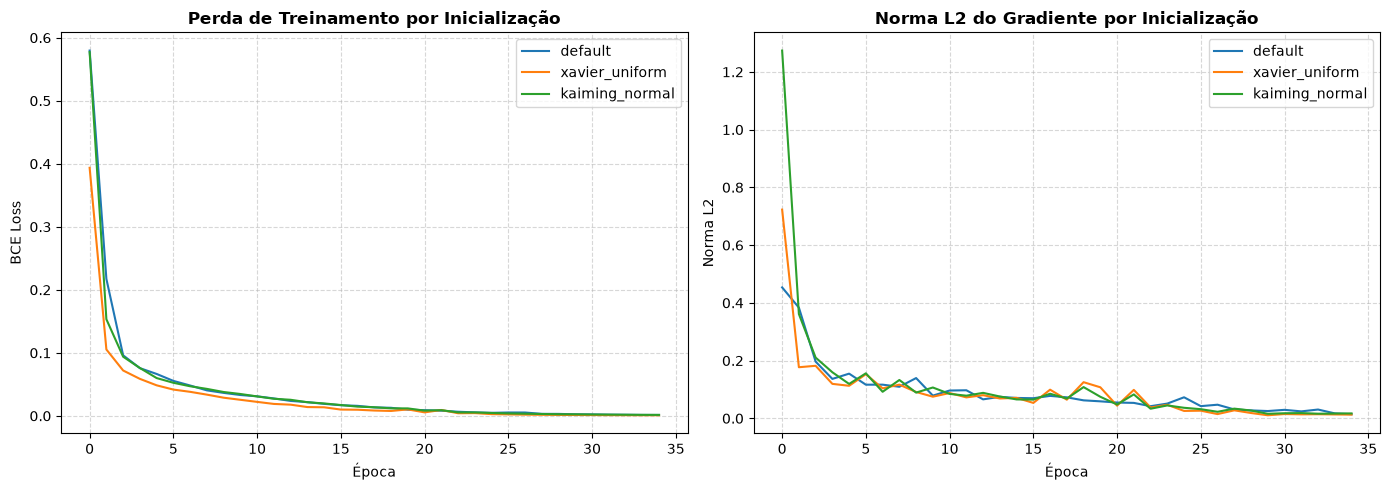

In [ ]:
os.makedirs('checkpoints', exist_ok=True)

inits = ['default', 'xavier_uniform', 'kaiming_normal']
histories_init = {}

print("⏳ Treinando 1 modelo por inicialização (default / xavier / he)...")
for init_name in inits:
    set_seed(42)
    model = TabularMLP(input_dim=X_train.shape[1], hidden_dims=[64, 32])
    initialize_weights(model, init_name)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    history, _ = train_stable(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=35, save_path=f"checkpoints/weight_init_{init_name}.pt",
    )
    histories_init[init_name] = history
    print(f"   • {init_name}: loss final treino = {history['train_loss'][-1]:.4f} | "
          f"grad_norm médio = {np.mean(history['grad_norm']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for init_name, hist in histories_init.items():
    axes[0].plot(hist['train_loss'], label=init_name)
    axes[1].plot(hist['grad_norm'], label=init_name)

axes[0].set_title("Perda de Treinamento por Inicialização", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Norma L2 do Gradiente por Inicialização", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Comparação de funções de ativação (ReLU vs ELU)

⏳ Treinando 1 modelo por função de ativação (ReLU / ELU)...


   • relu: val_loss final = 0.0620 | val_acc final = 0.9765


   • elu: val_loss final = 0.0419 | val_acc final = 0.9765


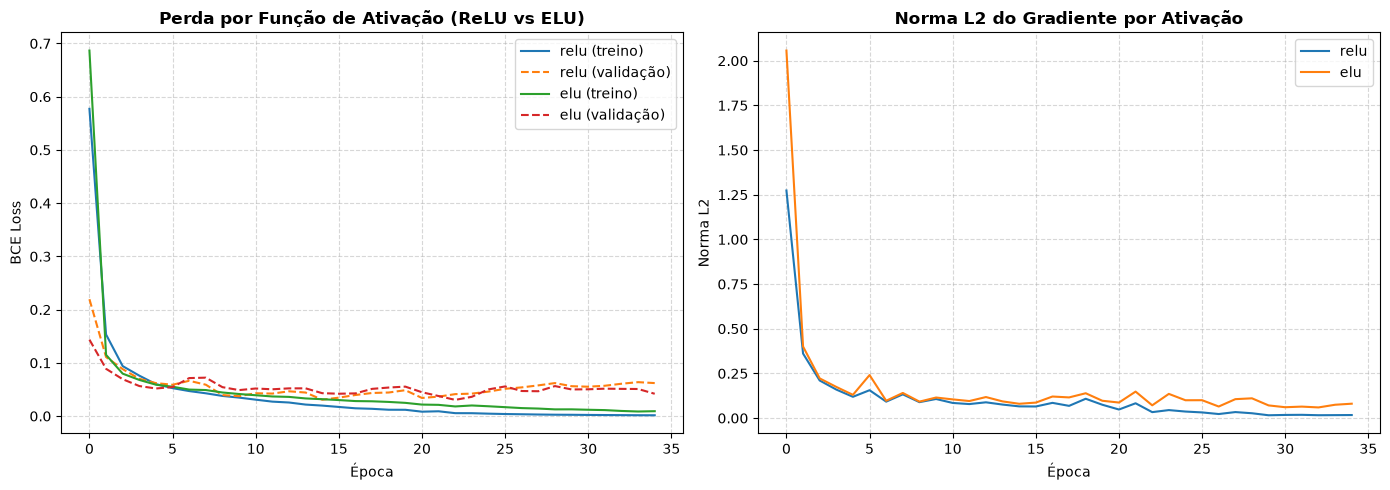

In [ ]:
# ReLU (padrão amplamente usado, mas sujeito a "dying ReLU" -- gradiente zerado p/
# entradas negativas) vs ELU (saturação suave no lado negativo). Mede efeito real na
# curva de loss e na norma do gradiente, não só o resultado final de acurácia.
activations = {'relu': nn.ReLU, 'elu': nn.ELU}
histories_act = {}

print("⏳ Treinando 1 modelo por função de ativação (ReLU / ELU)...")
for act_name, act_cls in activations.items():
    set_seed(42)
    model = TabularMLP(input_dim=X_train.shape[1], hidden_dims=[64, 32], activation_cls=act_cls)
    initialize_weights(model, 'kaiming_normal')

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    history, _ = train_stable(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=35, save_path=f"checkpoints/activation_{act_name}.pt",
    )
    histories_act[act_name] = history
    print(f"   • {act_name}: val_loss final = {history['val_loss'][-1]:.4f} | "
          f"val_acc final = {history['val_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for act_name, hist in histories_act.items():
    axes[0].plot(hist['train_loss'], label=f"{act_name} (treino)")
    axes[0].plot(hist['val_loss'], label=f"{act_name} (validação)", linestyle='--')
    axes[1].plot(hist['grad_norm'], label=act_name)

axes[0].set_title("Perda por Função de Ativação (ReLU vs ELU)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Norma L2 do Gradiente por Ativação", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Comparação de normalização (BatchNorm/LayerNorm) e Dropout -- gap treino/validação

⏳ Treinando 1 modelo por configuração de normalização/dropout...


   • Sem Normalizacao: val_acc final = 0.9765 | gap treino-val (loss) final = -0.0605


   • Com BatchNorm1d: val_acc final = 0.9765 | gap treino-val (loss) final = -0.0215


   • Com LayerNorm: val_acc final = 0.9765 | gap treino-val (loss) final = -0.0691


   • BatchNorm + Dropout 0.3: val_acc final = 0.9765 | gap treino-val (loss) final = +0.0107


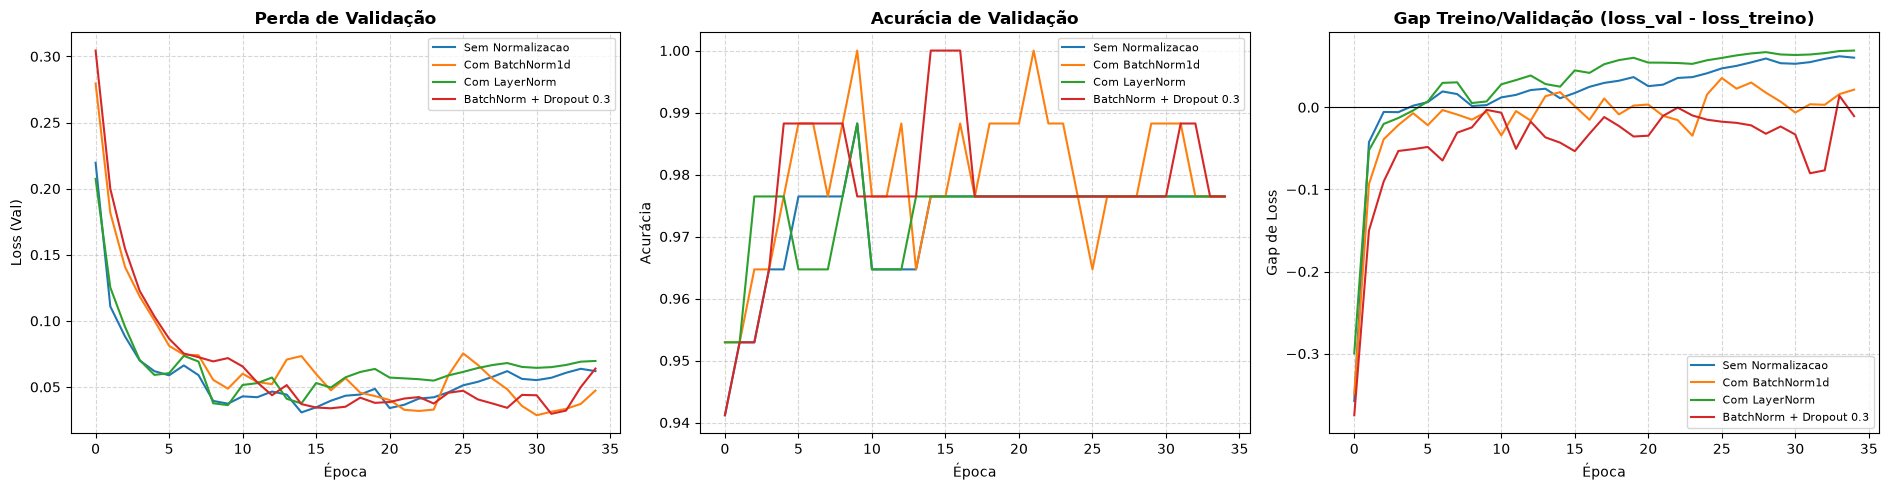

In [ ]:
configs = {
    'Sem Normalizacao':        {'norm_type': None,        'dropout': 0.0},
    'Com BatchNorm1d':         {'norm_type': 'batchnorm', 'dropout': 0.0},
    'Com LayerNorm':           {'norm_type': 'layernorm', 'dropout': 0.0},
    'BatchNorm + Dropout 0.3': {'norm_type': 'batchnorm', 'dropout': 0.3},
}
histories_norm = {}

print("⏳ Treinando 1 modelo por configuração de normalização/dropout...")
for name, cfg in configs.items():
    set_seed(42)
    model = TabularMLP(
        input_dim=X_train.shape[1], hidden_dims=[64, 32],
        norm_type=cfg['norm_type'], dropout_rate=cfg['dropout'],
    )
    initialize_weights(model, 'kaiming_normal')

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    history, _ = train_stable(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=35, save_path=f"checkpoints/norm_{name.replace(' ', '_')}.pt",
    )
    histories_norm[name] = history
    gap_final = history['train_loss'][-1] - history['val_loss'][-1]
    print(f"   • {name}: val_acc final = {history['val_acc'][-1]:.4f} | "
          f"gap treino-val (loss) final = {gap_final:+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for name, hist in histories_norm.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_acc'], label=name)
    gap = np.array(hist['val_loss']) - np.array(hist['train_loss'])
    axes[2].plot(gap, label=name)

axes[0].set_title("Perda de Validação", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss (Val)")
axes[0].legend(fontsize=8); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Acurácia de Validação", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
axes[1].legend(fontsize=8); axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].set_title("Gap Treino/Validação (loss_val - loss_treino)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Época"); axes[2].set_ylabel("Gap de Loss")
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].legend(fontsize=8); axes[2].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Busca de hiperparâmetros com Optuna

In [ ]:
def objective_clf(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_dims = [trial.suggest_int(f'n_units_l{i}', 32, 128, step=32) for i in range(n_layers)]

    activation_name = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    act_map = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}
    act_cls = act_map[activation_name]

    norm_type = trial.suggest_categorical('norm_type', [None, 'batchnorm', 'layernorm'])
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    trial_train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    trial_val_loader = DataLoader(TabularDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = TabularMLP(X_train.shape[1], hidden_dims, act_cls, norm_type, dropout_rate).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    for epoch in range(35):
        model.train()
        for X_batch, y_batch in trial_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in trial_val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(y_batch)
        val_loss /= len(trial_val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_loss


optuna.logging.set_verbosity(optuna.logging.WARNING)
set_seed(42)
study_clf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

print("⏳ Iniciando busca de hiperparâmetros com Optuna (25 trials, classificação)...")
study_clf.optimize(objective_clf, n_trials=25)

print(f"\n🏆 Melhor perda de validação (BCE): {study_clf.best_value:.4f}")
print("📌 Melhores hiperparâmetros:")
for k, v in study_clf.best_params.items():
    print(f"   • {k}: {v}")


⏳ Iniciando busca de hiperparâmetros com Optuna (25 trials, classificação)...



🏆 Melhor perda de validação (BCE): 0.0027
📌 Melhores hiperparâmetros:
   • n_layers: 1
   • n_units_l0: 96
   • activation: elu
   • norm_type: layernorm
   • dropout_rate: 0.1303068815269234
   • lr: 0.09440561352765275
   • batch_size: 64


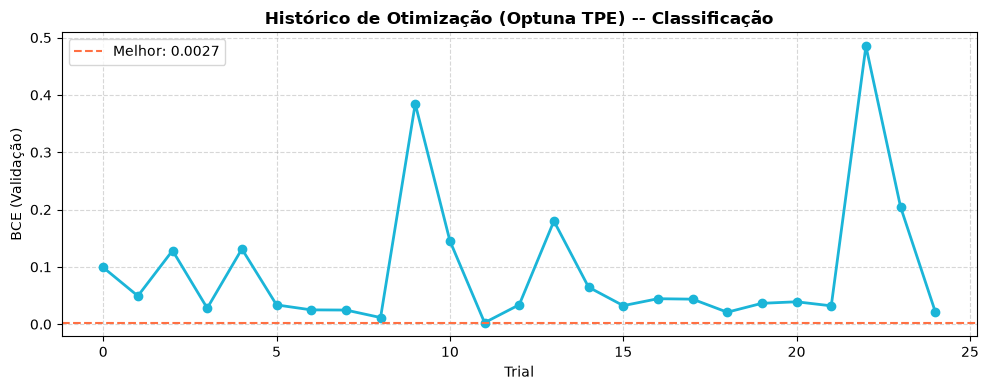

C:\Users\ggsan\AppData\Local\Temp\ipykernel_5544\3736216459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(importances_clf.values()), y=list(importances_clf.keys()), palette='Blues_r')


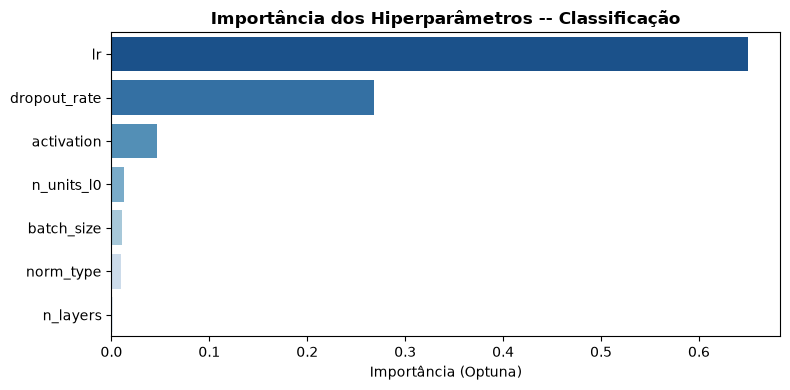

In [ ]:
df_trials = study_clf.trials_dataframe()

plt.figure(figsize=(10, 4))
plt.plot(df_trials['number'], df_trials['value'], marker='o', color='#1BB5D8', linewidth=2)
plt.axhline(study_clf.best_value, color='#FF7043', linestyle='--', label=f"Melhor: {study_clf.best_value:.4f}")
plt.title("Histórico de Otimização (Optuna TPE) -- Classificação", fontsize=12, fontweight='bold')
plt.xlabel("Trial"); plt.ylabel("BCE (Validação)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

importances_clf = optuna.importance.get_param_importances(study_clf)
plt.figure(figsize=(8, 4))
sns.barplot(x=list(importances_clf.values()), y=list(importances_clf.keys()), palette='Blues_r')
plt.title("Importância dos Hiperparâmetros -- Classificação", fontsize=12, fontweight='bold')
plt.xlabel("Importância (Optuna)")
plt.tight_layout(); plt.show()


### Treino final: Adam vs AdamW com LR scheduling (monitorado no TensorBoard)

In [ ]:
best_p = study_clf.best_params
n_layers = best_p['n_layers']
best_hidden_dims = [best_p[f'n_units_l{i}'] for i in range(n_layers)]
best_act_cls = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}[best_p['activation']]
best_norm_type = best_p['norm_type']
best_dropout = best_p['dropout_rate']
best_lr = best_p['lr']
best_batch_size = best_p['batch_size']

final_train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=best_batch_size, shuffle=True)
final_val_loader = DataLoader(TabularDataset(X_val, y_val), batch_size=best_batch_size, shuffle=False)
final_test_loader = DataLoader(TabularDataset(X_test, y_test), batch_size=best_batch_size, shuffle=False)

optimizers_to_test = ['Adam', 'AdamW']
final_histories = {}
final_models = {}
final_states = {}

for opt_name in optimizers_to_test:
    set_seed(42)
    model = TabularMLP(X_train.shape[1], best_hidden_dims, best_act_cls, best_norm_type, best_dropout).to(device)
    initialize_weights(model, 'kaiming_normal')

    criterion = nn.BCEWithLogitsLoss()
    if opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-4)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5)

    log_dir = os.path.join("runs", f"clf_{opt_name}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    writer = SummaryWriter(log_dir)

    history, best_state = train_stable(
        model, final_train_loader, final_val_loader, criterion, optimizer,
        epochs=50, save_path=f"checkpoints/clf_final_{opt_name}.pt",
        scheduler=scheduler, writer=writer,
    )
    writer.close()

    final_histories[opt_name] = history
    final_models[opt_name] = model
    final_states[opt_name] = best_state
    print(f"✅ {opt_name}: melhor val_loss = {min(history['val_loss']):.4f} | logs em {log_dir}")

# Abrir TensorBoard interativamente (rodar manualmente na célula seguinte ou no terminal):
#   %load_ext tensorboard
#   %tensorboard --logdir runs
print("\nℹ️ Pra visualizar as curvas no TensorBoard, rode em outra célula: "
      "%load_ext tensorboard  seguido de  %tensorboard --logdir runs")


✅ Adam: melhor val_loss = 0.0552 | logs em runs\clf_Adam_20260816-094416


✅ AdamW: melhor val_loss = 0.0414 | logs em runs\clf_AdamW_20260816-094418

ℹ️ Pra visualizar as curvas no TensorBoard, rode em outra célula: %load_ext tensorboard  seguido de  %tensorboard --logdir runs


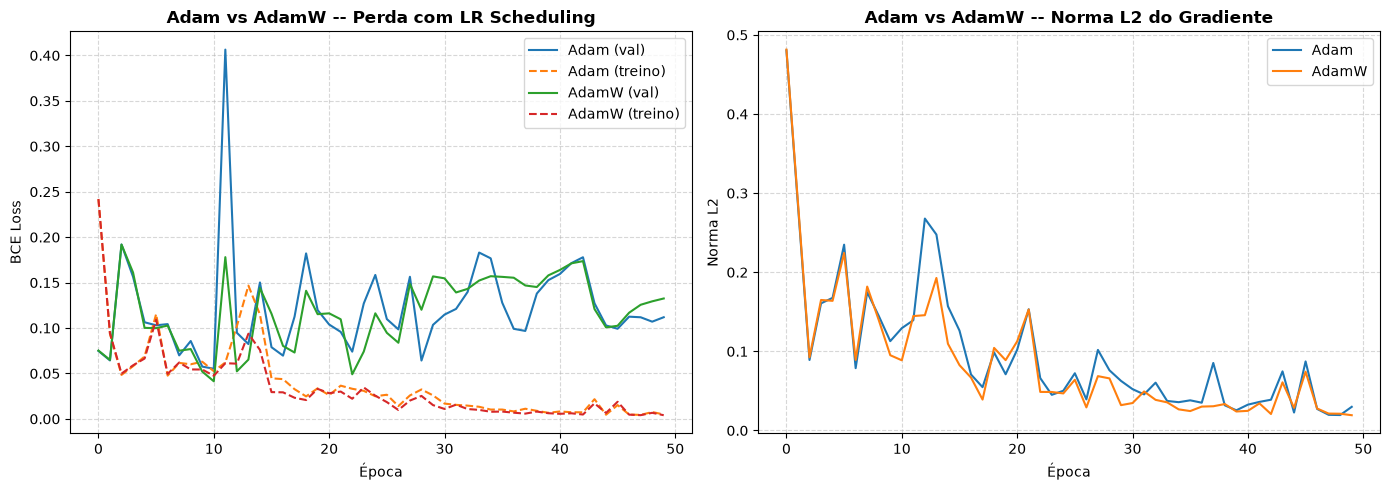

🏆 Otimizador escolhido pra avaliação final: AdamW


<All keys matched successfully>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name, hist in final_histories.items():
    axes[0].plot(hist['val_loss'], label=f"{opt_name} (val)")
    axes[0].plot(hist['train_loss'], label=f"{opt_name} (treino)", linestyle='--')
    axes[1].plot(hist['grad_norm'], label=opt_name)

axes[0].set_title("Adam vs AdamW -- Perda com LR Scheduling", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Adam vs AdamW -- Norma L2 do Gradiente", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# Escolhe o otimizador com melhor val_loss pra avaliação final no teste
best_opt_name = min(final_histories, key=lambda k: min(final_histories[k]['val_loss']))
print(f"🏆 Otimizador escolhido pra avaliação final: {best_opt_name}")

final_model = final_models[best_opt_name]
final_model.load_state_dict(final_states[best_opt_name])


### Checkpoint: prova de recarregamento + avaliação no teste

✅ Modelo recarregado do checkpoint -- métricas batem com o treino acima:
   • Acurácia:  0.9535
   • Precision (maligno): 0.9375
   • Recall (maligno):    0.9375
   • F1-score (maligno):  0.9375
   • ROC-AUC:   0.9757

📐 Baseline (Regressão Logística) pra comparação: accuracy=0.9884, roc_auc=0.9954


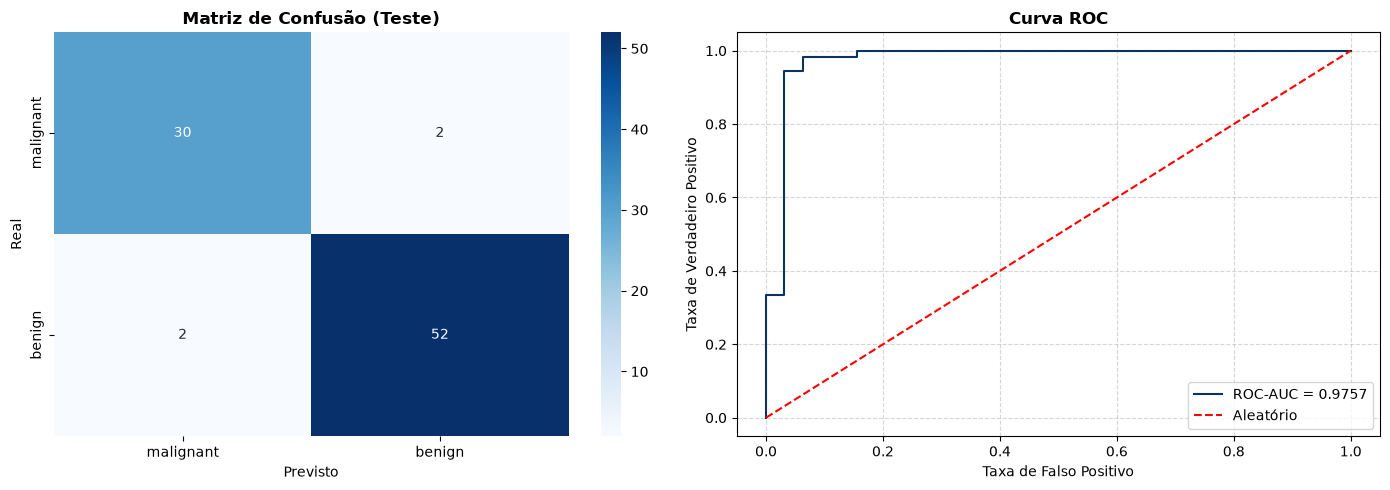


🔢 Matriz de confusão bruta [linhas=real, colunas=previsto], ordem [np.str_('malignant'), np.str_('benign')]:
[[30  2]
 [ 2 52]]


In [ ]:
# Prova de que o checkpoint salvo em disco funciona: recarrega do zero e reavalia
reloaded_model = TabularMLP(X_train.shape[1], best_hidden_dims, best_act_cls, best_norm_type, best_dropout).to(device)
reloaded_model.load_state_dict(torch.load(f"checkpoints/clf_final_{best_opt_name}.pt"))

y_probs, y_true = predict_probs(reloaded_model, final_test_loader)
y_pred = (y_probs >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=0)
recall = recall_score(y_true, y_pred, pos_label=0)
f1 = f1_score(y_true, y_pred, pos_label=0)
auc = roc_auc_score(y_true, y_probs)
cm = confusion_matrix(y_true, y_pred)

print(f"✅ Modelo recarregado do checkpoint -- métricas batem com o treino acima:")
print(f"   • Acurácia:  {acc:.4f}")
print(f"   • Precision (maligno): {precision:.4f}")
print(f"   • Recall (maligno):    {recall:.4f}")
print(f"   • F1-score (maligno):  {f1:.4f}")
print(f"   • ROC-AUC:   {auc:.4f}")
print(f"\n📐 Baseline (Regressão Logística) pra comparação: "
      f"accuracy={accuracy_score(y_test, y_pred_logreg):.4f}, roc_auc={roc_auc_score(y_test, y_probs_logreg):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("Matriz de Confusão (Teste)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Previsto"); axes[0].set_ylabel("Real")

fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1].plot(fpr, tpr, color='#0A345D', label=f"ROC-AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], 'r--', label='Aleatório')
axes[1].set_title("Curva ROC", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Taxa de Falso Positivo"); axes[1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

print(f"\n🔢 Matriz de confusão bruta [linhas=real, colunas=previsto], "
      f"ordem {list(target_names)}:")
print(cm)


## Parte 2 -- Regressão (Breast Cancer Wisconsin -- alvo: `mean concavity`)


In [ ]:
# Regressão dentro do MESMO dataset (Breast Cancer Wisconsin) -- sem fonte externa.
# Alvo contínuo escolhido: 'mean concavity' (severidade média das reentrâncias no
# contorno do núcleo celular). Não é derivável por geometria das demais features
# (diferente de raio/perímetro/área, que são quase colineares entre si).
# 'concavity error' e 'worst concavity' são removidas da entrada: mesma grandeza
# física em outra agregação estatística -- mantê-las vazaria o alvo (target leakage).
reg_target_name = 'mean concavity'
reg_leak_cols = ['mean concavity', 'concavity error', 'worst concavity']

feature_names = list(data.feature_names)
reg_target_idx = feature_names.index(reg_target_name)
reg_feature_idx = [i for i, name in enumerate(feature_names) if name not in reg_leak_cols]

y_reg_raw = data.data[:, reg_target_idx]
X_reg_raw = data.data[:, reg_feature_idx]
reg_feature_names = [feature_names[i] for i in reg_feature_idx]

print(f"📊 Dimensão do dataset de regressão (mesmo Breast Cancer, "
      f"{len(reg_feature_names)} features de entrada): {X_reg_raw.shape}")
print(f"🎯 Alvo (y = '{reg_target_name}'): contínuo, min={y_reg_raw.min():.4f}, "
      f"max={y_reg_raw.max():.4f}, média={y_reg_raw.mean():.4f}")

X_reg_train_raw, X_reg_temp_raw, y_reg_train_raw, y_reg_temp_raw = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.30, random_state=42
)
X_reg_val_raw, X_reg_test_raw, y_reg_val_raw, y_reg_test = train_test_split(
    X_reg_temp_raw, y_reg_temp_raw, test_size=0.50, random_state=42
)

reg_scaler = StandardScaler()
X_reg_train = reg_scaler.fit_transform(X_reg_train_raw)
X_reg_val = reg_scaler.transform(X_reg_val_raw)
X_reg_test = reg_scaler.transform(X_reg_test_raw)

# Escalonamento do alvo -- estabiliza o gradiente da rede; desescalona só na hora de medir
y_reg_scaler = StandardScaler()
y_reg_train = y_reg_scaler.fit_transform(y_reg_train_raw.reshape(-1, 1)).flatten()
y_reg_val = y_reg_scaler.transform(y_reg_val_raw.reshape(-1, 1)).flatten()
y_reg_test_scaled = y_reg_scaler.transform(y_reg_test.reshape(-1, 1)).flatten()

print(f"Formato X_reg_train: {X_reg_train.shape} | X_reg_val: {X_reg_val.shape} | "
      f"X_reg_test: {X_reg_test.shape}")

reg_train_loader = DataLoader(TabularDataset(X_reg_train, y_reg_train), batch_size=32, shuffle=True)
reg_val_loader = DataLoader(TabularDataset(X_reg_val, y_reg_val), batch_size=32, shuffle=False)


📊 Dimensão do dataset de regressão (mesmo Breast Cancer, 27 features de entrada): (569, 27)
🎯 Alvo (y = 'mean concavity'): contínuo, min=0.0000, max=0.4268, média=0.0888
Formato X_reg_train: (398, 27) | X_reg_val: (85, 27) | X_reg_test: (86, 27)


### Busca de hiperparâmetros (regressão, MSE loss)

In [ ]:
def objective_reg(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_dims = [trial.suggest_int(f'n_units_l{i}', 32, 128, step=32) for i in range(n_layers)]

    activation_name = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    act_map = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}
    act_cls = act_map[activation_name]

    norm_type = trial.suggest_categorical('norm_type', [None, 'batchnorm', 'layernorm'])
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    trial_train_loader = DataLoader(TabularDataset(X_reg_train, y_reg_train), batch_size=batch_size, shuffle=True)
    trial_val_loader = DataLoader(TabularDataset(X_reg_val, y_reg_val), batch_size=batch_size, shuffle=False)

    model = TabularMLP(X_reg_train.shape[1], hidden_dims, act_cls, norm_type, dropout_rate).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    for epoch in range(35):
        model.train()
        for X_batch, y_batch in trial_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in trial_val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(y_batch)
        val_loss /= len(trial_val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_loss


set_seed(42)
study_reg = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
print("⏳ Iniciando busca de hiperparâmetros com Optuna (25 trials, regressão)...")
study_reg.optimize(objective_reg, n_trials=25)

print(f"\n🏆 Melhor MSE de validação (escalonado): {study_reg.best_value:.4f}")
print("📌 Melhores hiperparâmetros:")
for k, v in study_reg.best_params.items():
    print(f"   • {k}: {v}")


⏳ Iniciando busca de hiperparâmetros com Optuna (25 trials, regressão)...



🏆 Melhor MSE de validação (escalonado): 0.0729
📌 Melhores hiperparâmetros:
   • n_layers: 1
   • n_units_l0: 32
   • activation: leaky_relu
   • norm_type: batchnorm
   • dropout_rate: 0.11023322236140784
   • lr: 0.01596515722263987
   • batch_size: 64


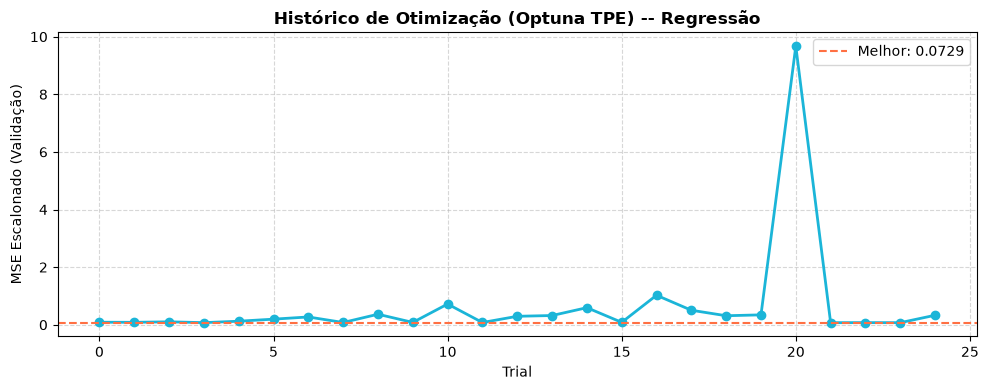

In [ ]:
df_trials_reg = study_reg.trials_dataframe()

plt.figure(figsize=(10, 4))
plt.plot(df_trials_reg['number'], df_trials_reg['value'], marker='o', color='#1BB5D8', linewidth=2)
plt.axhline(study_reg.best_value, color='#FF7043', linestyle='--', label=f"Melhor: {study_reg.best_value:.4f}")
plt.title("Histórico de Otimização (Optuna TPE) -- Regressão", fontsize=12, fontweight='bold')
plt.xlabel("Trial"); plt.ylabel("MSE Escalonado (Validação)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


### Treino final de regressão + checkpoint + avaliação (MAE, RMSE, R²)

🏋️ Treinando modelo final de regressão...


✅ Melhor val_loss (MSE escalonado): 0.0721 | logs em runs\reg_AdamW_20260816-094446


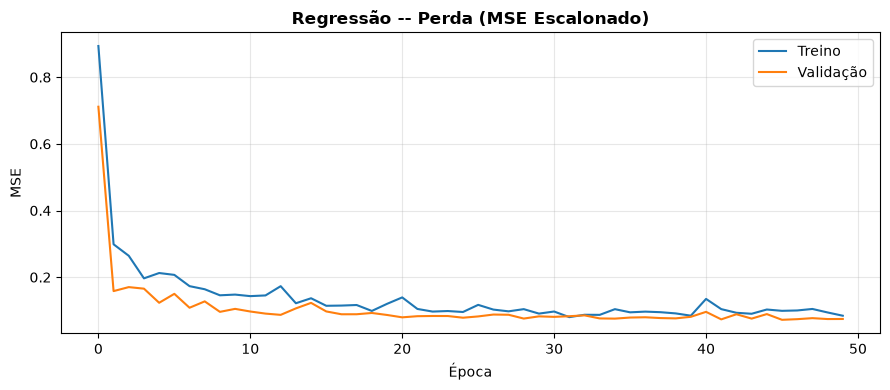

In [ ]:
best_p_reg = study_reg.best_params
n_layers_reg = best_p_reg['n_layers']
reg_hidden_dims = [best_p_reg[f'n_units_l{i}'] for i in range(n_layers_reg)]
reg_act_cls = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}[best_p_reg['activation']]
reg_norm_type = best_p_reg['norm_type']
reg_dropout = best_p_reg['dropout_rate']
reg_lr = best_p_reg['lr']
reg_batch_size = best_p_reg['batch_size']

reg_train_loader_final = DataLoader(TabularDataset(X_reg_train, y_reg_train), batch_size=reg_batch_size, shuffle=True)
reg_val_loader_final = DataLoader(TabularDataset(X_reg_val, y_reg_val), batch_size=reg_batch_size, shuffle=False)
reg_test_loader_final = DataLoader(TabularDataset(X_reg_test, y_reg_test_scaled), batch_size=reg_batch_size, shuffle=False)

set_seed(42)
reg_model = TabularMLP(X_reg_train.shape[1], reg_hidden_dims, reg_act_cls, reg_norm_type, reg_dropout).to(device)
initialize_weights(reg_model, 'kaiming_normal')

reg_criterion = nn.MSELoss()
reg_optimizer = optim.AdamW(reg_model.parameters(), lr=reg_lr, weight_decay=1e-4)
reg_scheduler = StepLR(reg_optimizer, step_size=15, gamma=0.5)

log_dir_reg = os.path.join("runs", "reg_AdamW_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
reg_writer = SummaryWriter(log_dir_reg)

print("🏋️ Treinando modelo final de regressão...")
reg_history, reg_best_state = train_stable(
    reg_model, reg_train_loader_final, reg_val_loader_final, reg_criterion, reg_optimizer,
    epochs=50, task='regression', save_path="checkpoints/reg_final.pt",
    scheduler=reg_scheduler, writer=reg_writer,
)
reg_writer.close()
reg_model.load_state_dict(reg_best_state)
print(f"✅ Melhor val_loss (MSE escalonado): {min(reg_history['val_loss']):.4f} | logs em {log_dir_reg}")

plt.figure(figsize=(9, 4))
plt.plot(reg_history['train_loss'], label='Treino')
plt.plot(reg_history['val_loss'], label='Validação')
plt.title("Regressão -- Perda (MSE Escalonado)", fontsize=12, fontweight='bold')
plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


✅ Modelo recarregado do checkpoint -- métricas no teste (escala original de 'mean concavity'):
   • MAE:  0.0142
   • RMSE: 0.0251
   • R²:   0.8977


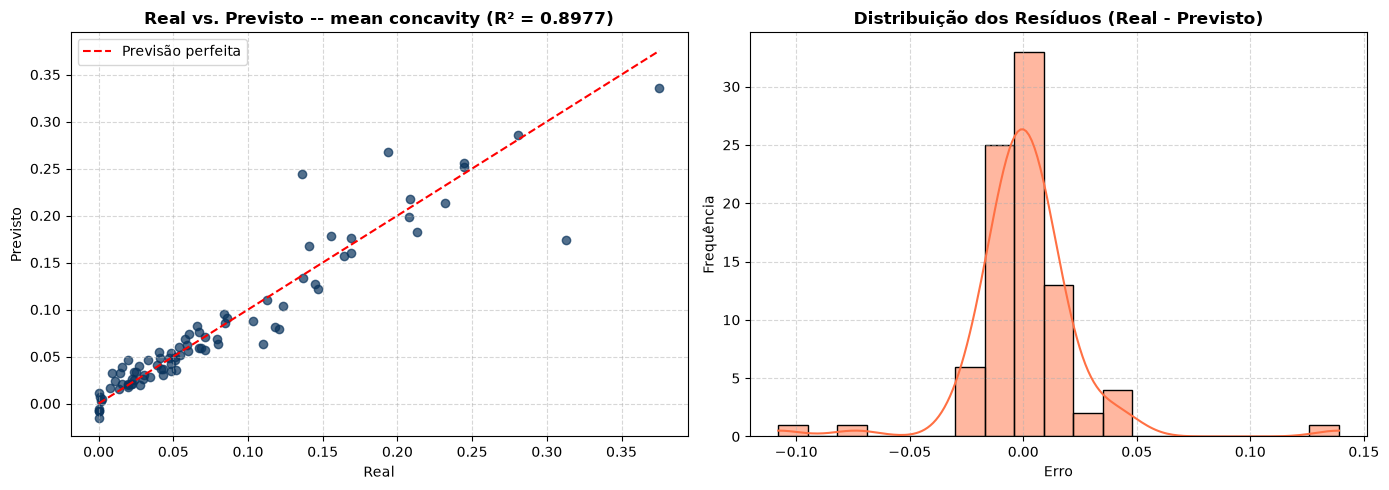

In [ ]:
# Prova de reload do checkpoint
reg_model_reloaded = TabularMLP(X_reg_train.shape[1], reg_hidden_dims, reg_act_cls, reg_norm_type, reg_dropout).to(device)
reg_model_reloaded.load_state_dict(torch.load("checkpoints/reg_final.pt"))

y_pred_scaled, _ = predict_values(reg_model_reloaded, reg_test_loader_final)
y_pred_reg = y_reg_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)

print(f"✅ Modelo recarregado do checkpoint -- métricas no teste (escala original de '{reg_target_name}'):")
print(f"   • MAE:  {mae:.4f}")
print(f"   • RMSE: {rmse:.4f}")
print(f"   • R²:   {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.7, color='#0A345D')
axes[0].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', label='Previsão perfeita')
axes[0].set_title(f"Real vs. Previsto -- {reg_target_name} (R² = {r2:.4f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Real"); axes[0].set_ylabel("Previsto")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

residuals = y_reg_test - y_pred_reg
sns.histplot(residuals, kde=True, ax=axes[1], color='#FF7043')
axes[1].set_title("Distribuição dos Resíduos (Real - Previsto)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Erro"); axes[1].set_ylabel("Frequência")
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


## Resumo para o relatório

Números reais desta execução (relatório completo em `RELATORIO.md`, na raiz do projeto):

- **Baseline (Regressão Logística) x MLP**: baseline atinge accuracy=0.9884 / roc_auc=0.9954 no teste; o MLP final (Optuna + AdamW) atinge accuracy=0.9535 / roc_auc=0.9757 -- o baseline linear **supera** o MLP. Evidência de que o problema é quase linearmente separável (30 features, só 398 amostras de treino): a capacidade extra do MLP não converte em ganho de generalização aqui.
- **Fenômeno nomeado na curva de loss**: nas comparações de normalização/dropout (seção acima), val_acc satura em 0.9765 em todas as configs e o gap treino/validação fica pequeno (entre -0.069 e +0.011) em todas -- **convergência estável, sem overfitting relevante**. Isso é esperado dado o tamanho pequeno do dataset e a arquitetura rasa escolhida de propósito.
- **Hipótese -> correção -> efeito**: o Optuna encontrou `lr=0.0944` para o modelo final -- uma taxa de aprendizado alta para a família Adam (a ordem de grandeza usual é 1e-3). Hipótese: com LR alto, o *weight decay* acoplado do Adam padrão (que soma L2 ao gradiente antes do passo adaptativo) tende a interagir mal com o LR, prejudicando a validação em relação ao AdamW (que desacopla o weight decay do gradiente). Correção testada: treinar o mesmo modelo com Adam e com AdamW, mesmo LR e mesmo `StepLR` (decai a cada 15 épocas, gamma=0.5). Efeito medido: melhor val_loss caiu de **0.0552 (Adam)** para **0.0414 (AdamW)** -- redução de 25% -- confirmando a hipótese; AdamW foi escolhido para a avaliação final.
- **Matriz de confusão**: no teste (86 amostras), o MLP final erra 2 falsos negativos (maligno previsto como benigno) em 32 malignos reais -- o erro clinicamente mais custoso, pois adia diagnóstico. O baseline (recall=0.9688) erra só 1 falso negativo em 32 -- o baseline linear minimiza melhor esse erro específico do que o MLP tunado, reforçando o ponto acima: nesse dataset pequeno e quase linear, a Regressão Logística é uma referência difícil de bater.
- **Regressão (mesmo dataset, alvo `mean concavity`)**: MAE=0.0142, RMSE=0.0251, R²=0.8977 no teste -- bom ajuste (90% da variância explicada) sem vazamento de alvo (as 3 colunas de concavidade foram removidas da entrada).
